In [1]:
import numpy as np
import matplotlib.pyplot as plt
E_F = 12.2400  # Fermi energy in eV
def load_data(filename,up_index=2,down_index=3):

     # load data
     data = np.loadtxt(filename)

     E = np.unique(data[:, 1])
     k = np.unique(data[:, 0])

     dosup = np.zeros([len(k),len(E)])
     dosdown = np.zeros([len(k),len(E)])

     for i in range(len(data)):
         E_index = int(i % len(E))
         k_index = int(data[i][0] - 1)

         dosup[k_index, E_index] = data[i][up_index]
         dosdown[k_index, E_index] = data[i][down_index]
         if dosup[k_index, E_index]<0: dosup[k_index, E_index]=0
         if dosdown[k_index, E_index]<0: dosdown[k_index, E_index]=0

     return k,E,dosup,dosdown


In [2]:
k, E, DoStotalup, DoStotaldown = load_data('Ru_pdos.k.dat.pdos_tot')


k,E,DoSRu1up, DoSRu1down= load_data('Ru_pdos.k.dat.pdos_atm#1(Ru1)_wfc#4(d)')
k,E,DoSRu2up, DoSRu2down = load_data('Ru_pdos.k.dat.pdos_atm#2(Ru2)_wfc#4(d)')

DoSRuup = DoSRu1up + DoSRu2up
DoSRudown = DoSRu1down + DoSRu2down

k,E,DoSO1up, DoSO1down = load_data('Ru_pdos.k.dat.pdos_atm#3(O)_wfc#2(p)')
k,E,DoSO2up, DoSO2down = load_data('Ru_pdos.k.dat.pdos_atm#4(O)_wfc#2(p)')
k,E,DoSO3up, DoSO3down = load_data('Ru_pdos.k.dat.pdos_atm#5(O)_wfc#2(p)')
k,E,DoSO4up, DoSO4down = load_data('Ru_pdos.k.dat.pdos_atm#6(O)_wfc#2(p)')
DoSOup = DoSO1up + DoSO2up + DoSO3up + DoSO4up
DoSOdown = DoSO1down + DoSO2down + DoSO3down + DoSO4down

k, E, DoSRu1dz2up, DoSRu1dz2down = load_data('Ru_pdos.k.dat.pdos_atm#1(Ru1)_wfc#4(d)', up_index=4, down_index=5)
k, E, DoSRu2dz2up, DoSRu2dz2down = load_data('Ru_pdos.k.dat.pdos_atm#2(Ru2)_wfc#4(d)', up_index=4, down_index=5)
DoSRudz2up = DoSRu1dz2up + DoSRu2dz2up
DoSRudz2down = DoSRu1dz2down + DoSRu2dz2down


k, E, DoSRu1dzxup, DoSRu1dzxdown = load_data('Ru_pdos.k.dat.pdos_atm#1(Ru1)_wfc#4(d)', up_index=6, down_index=7)
k, E, DoSRu2dzxup, DoSRu2dzxdown = load_data('Ru_pdos.k.dat.pdos_atm#2(Ru2)_wfc#4(d)', up_index=6, down_index=7)
DoSRudzxup = DoSRu1dzxup + DoSRu2dzxup
DoSRudzxdown = DoSRu1dzxdown + DoSRu2dzxdown


k, E, DoSRu1dzyup, DoSRu1dzydown = load_data('Ru_pdos.k.dat.pdos_atm#1(Ru1)_wfc#4(d)', up_index=8, down_index=9)
k, E, DoSRu2dzyup, DoSRu2dzydown = load_data('Ru_pdos.k.dat.pdos_atm#2(Ru2)_wfc#4(d)', up_index=8, down_index=9)
DoSRudzyup = DoSRu1dzyup + DoSRu2dzyup
DoSRudzydown = DoSRu1dzydown + DoSRu2dzydown


k, E, DoSRu1dx2y2up, DoSRu1dx2y2down = load_data('Ru_pdos.k.dat.pdos_atm#1(Ru1)_wfc#4(d)', up_index=10, down_index=11)
k, E, DoSRu2dx2y2up, DoSRu2dx2y2down = load_data('Ru_pdos.k.dat.pdos_atm#2(Ru2)_wfc#4(d)', up_index=10, down_index=11)
DoSRudx2y2up = DoSRu1dx2y2up + DoSRu2dx2y2up
DoSRudx2y2down = DoSRu1dx2y2down + DoSRu2dx2y2down


k, E, DoSRu1dxyup, DoSRu1dxydown = load_data('Ru_pdos.k.dat.pdos_atm#1(Ru1)_wfc#4(d)', up_index=12, down_index=13)
k, E, DoSRu2dxyup, DoSRu2dxydown = load_data('Ru_pdos.k.dat.pdos_atm#2(Ru2)_wfc#4(d)', up_index=12, down_index=13)
DoSRudxyup = DoSRu1dxyup + DoSRu2dxyup
DoSRudxydown = DoSRu1dxydown + DoSRu2dxydown



In [18]:
xtik = np.array([0.0000, 0.5000 ,1.2248, 1.7248, 2.4496, 3.1567, 3.8814 , 4.5886]) * len(k)/ 4.5886
xtiklabel = np.array(['$\Gamma$', 'X', 'R', 'Z', '$\Gamma$', 'M', 'A', 'Z'])
# Calculate the relative projected DoS of Ru d orbitals with respect to the total DoS
with np.errstate(divide='ignore', invalid='ignore'):
    totalDoS = DoStotalup + DoStotaldown

    DoSRuup_rel = np.where(totalDoS != 0, DoSRuup / totalDoS, 0)
    DoSRudown_rel = np.where(totalDoS != 0, DoSRudown / totalDoS, 0)

    DoSRudz2up_rel = np.where(totalDoS != 0, DoSRudz2up / totalDoS, 0)
    DoSRudz2down_rel = np.where(totalDoS != 0, DoSRudz2down / totalDoS, 0)

    DoSRudzxup_rel = np.where(totalDoS != 0, DoSRudzxup / totalDoS, 0)
    DoSRudzxdown_rel = np.where(totalDoS != 0, DoSRudzxdown / totalDoS, 0)

    DoSRudzyup_rel = np.where(totalDoS != 0, DoSRudzyup / totalDoS, 0)
    DoSRudzydown_rel = np.where(totalDoS != 0, DoSRudzydown / totalDoS, 0)

    DoSRudx2y2up_rel = np.where(totalDoS != 0, DoSRudx2y2up / totalDoS, 0)
    DoSRudx2y2down_rel = np.where(totalDoS != 0, DoSRudx2y2down / totalDoS, 0)

    DoSRudxyup_rel = np.where(totalDoS != 0, DoSRudxyup / totalDoS, 0)
    DoSRudxydown_rel = np.where(totalDoS != 0, DoSRudxydown / totalDoS, 0)

    DoSOup_rel = np.where(totalDoS != 0, DoSOup / totalDoS, 0)
    DoSOdown_rel = np.where(totalDoS != 0, DoSOdown / totalDoS, 0)

<>:2: SyntaxWarning: invalid escape sequence '\G'
<>:2: SyntaxWarning: invalid escape sequence '\G'
<>:2: SyntaxWarning: invalid escape sequence '\G'
<>:2: SyntaxWarning: invalid escape sequence '\G'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_23932\4218356150.py:2: SyntaxWarning: invalid escape sequence '\G'
  xtiklabel = np.array(['$\Gamma$', 'X', 'R', 'Z', '$\Gamma$', 'M', 'A', 'Z'])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_23932\4218356150.py:2: SyntaxWarning: invalid escape sequence '\G'
  xtiklabel = np.array(['$\Gamma$', 'X', 'R', 'Z', '$\Gamma$', 'M', 'A', 'Z'])


Text(0.5, 0.98, 'Ru $d$-orbital projected DoS (relative)')

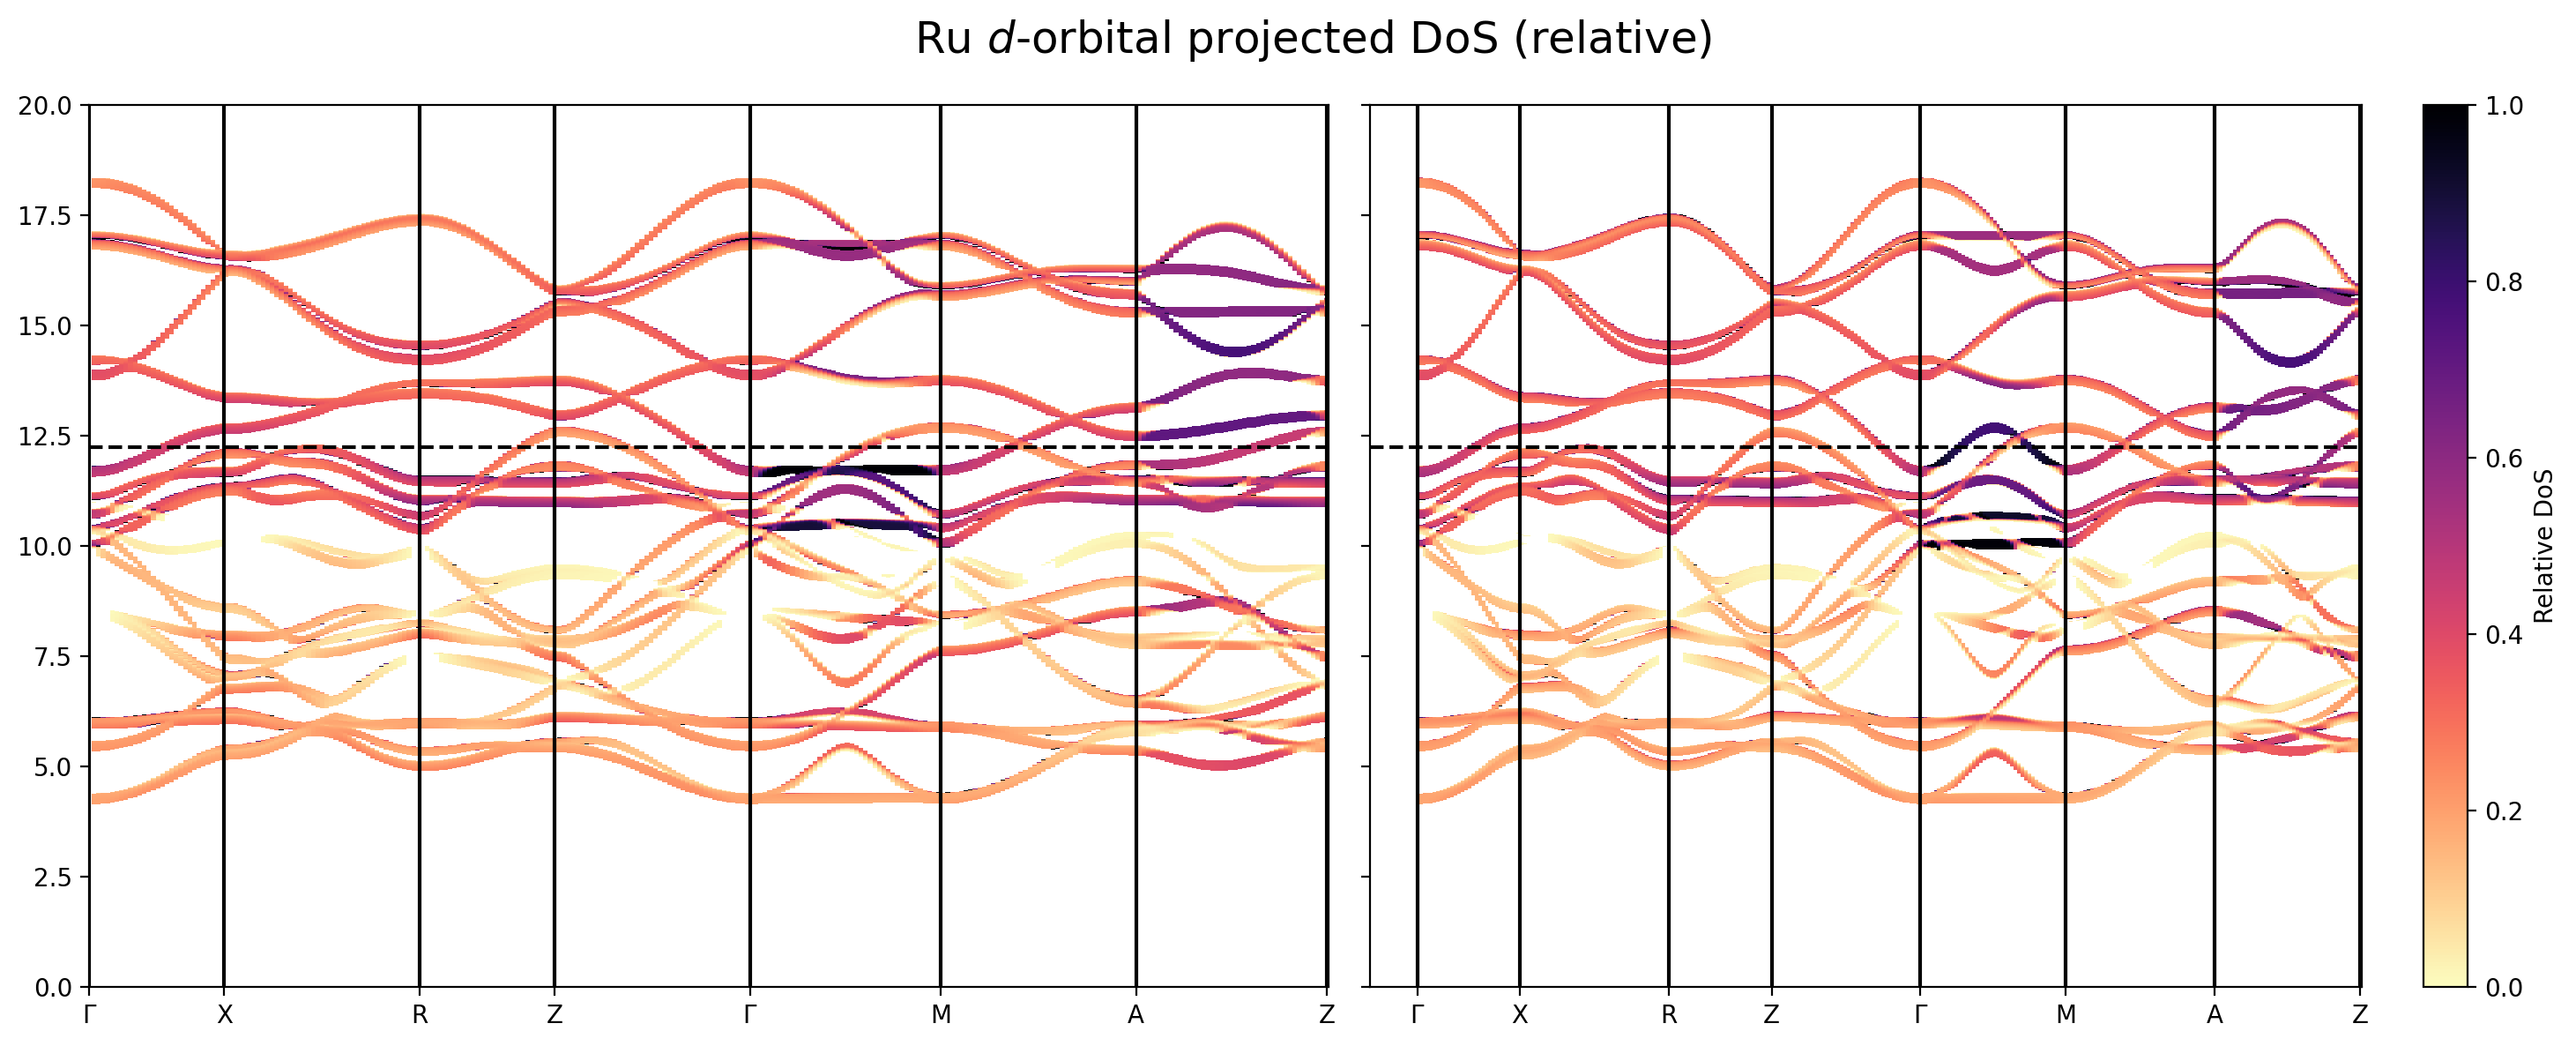

In [30]:
cmr = plt.cm.magma_r
cmr.set_bad(color='white')
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True, tight_layout=True, dpi=200)
cmr.set_under('lightgray')
band_mask = DoSRuup_rel < 0.01
DoSRuup_rel_masked = np.ma.masked_where(band_mask, DoSRuup_rel)
ax[0].axhline(y=E_F, label='Fermi level', color='black', linestyle='--')
ax[0].set_ylim(0, 20)
ax[0].pcolormesh(k, E, DoSRuup_rel_masked.T, cmap=cmr, vmin=0, vmax=1)
ax[0].set_xticks(xtik)
ax[0].set_xticklabels(xtiklabel)
for i in range(len(xtik)):
    ax[0].axvline(x=xtik[i], color='black', linestyle='-')
    ax[1].axvline(x=xtik[i], color='black', linestyle='-')
band_mask = DoSRudown_rel < 0.01
DoSRudown_rel_masked = np.ma.masked_where(band_mask, DoSRudown_rel)
ax[1].axhline(y=E_F, label='Fermi level', color='black', linestyle='--')
ax[1].pcolormesh(k, E, DoSRudown_rel_masked.T, cmap=cmr, vmin=0, vmax=1)
ax[1].set_xticks(xtik)
ax[1].set_xticklabels(xtiklabel)
plt.colorbar(ax[1].collections[0], ax=ax[1], label='Relative DoS')
fig.suptitle('Ru $d$-orbital projected DoS (relative)', fontsize=18)

Text(0.5, 0.98, 'O $p$-orbital projected DoS')

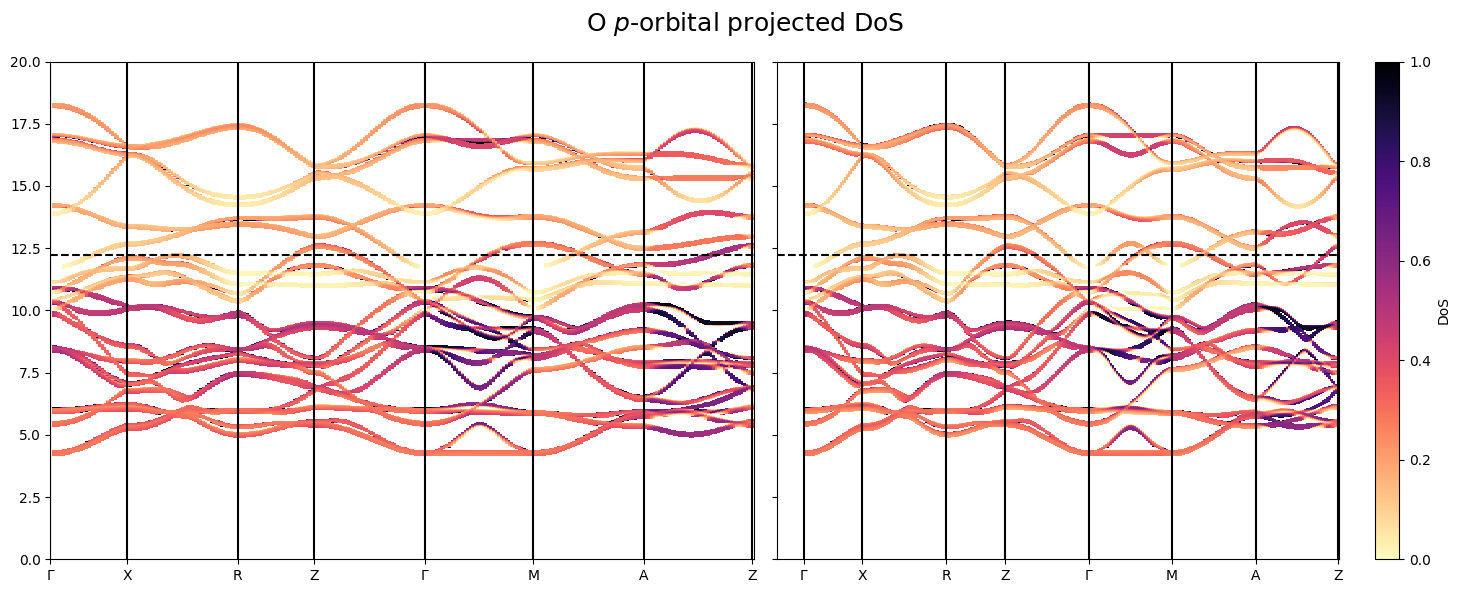

In [23]:
cmr = plt.cm.magma_r
cmr.set_bad(color='white')
fig, ax = plt.subplots(1,2,figsize=(15, 6),sharey=True, tight_layout=True)

band_mask = DoSOup_rel < 0.01
DoSOup_rel_masked = np.ma.masked_where(band_mask, DoSOup_rel)
ax[0].axhline(y = E_F, label='Fermi level', color='black', linestyle='--')
ax[0].set_ylim(0, 20)
pcm0 = ax[0].pcolormesh(k, E, DoSOup_rel_masked.T, cmap=cmr, vmin=0, vmax=1)
ax[0].set_xticks(xtik)
ax[0].set_xticklabels(xtiklabel)
for i in range(len(xtik)):
    ax[0].axvline(x = xtik[i], color='black', linestyle='-')
    ax[1].axvline(x = xtik[i], color='black', linestyle='-')
band_mask = DoSOdown_rel < 0.01
DoSOdown_rel_masked = np.ma.masked_where(band_mask, DoSOdown_rel)
ax[1].axhline(y = E_F, label='Fermi level', color='black', linestyle='--')
pcm1 = ax[1].pcolormesh(k, E, DoSOdown_rel_masked.T, cmap=cmr, vmin=0, vmax=1)
ax[1].set_xticks(xtik)
ax[1].set_xticklabels(xtiklabel)
plt.colorbar(pcm1, ax=ax[1], label='DoS', extend='neither')
fig.suptitle('O $p$-orbital projected DoS', fontsize=18)

Text(0.5, 0.98, 'Ru $d_{z^2}$-orbital projected DoS (relative)')

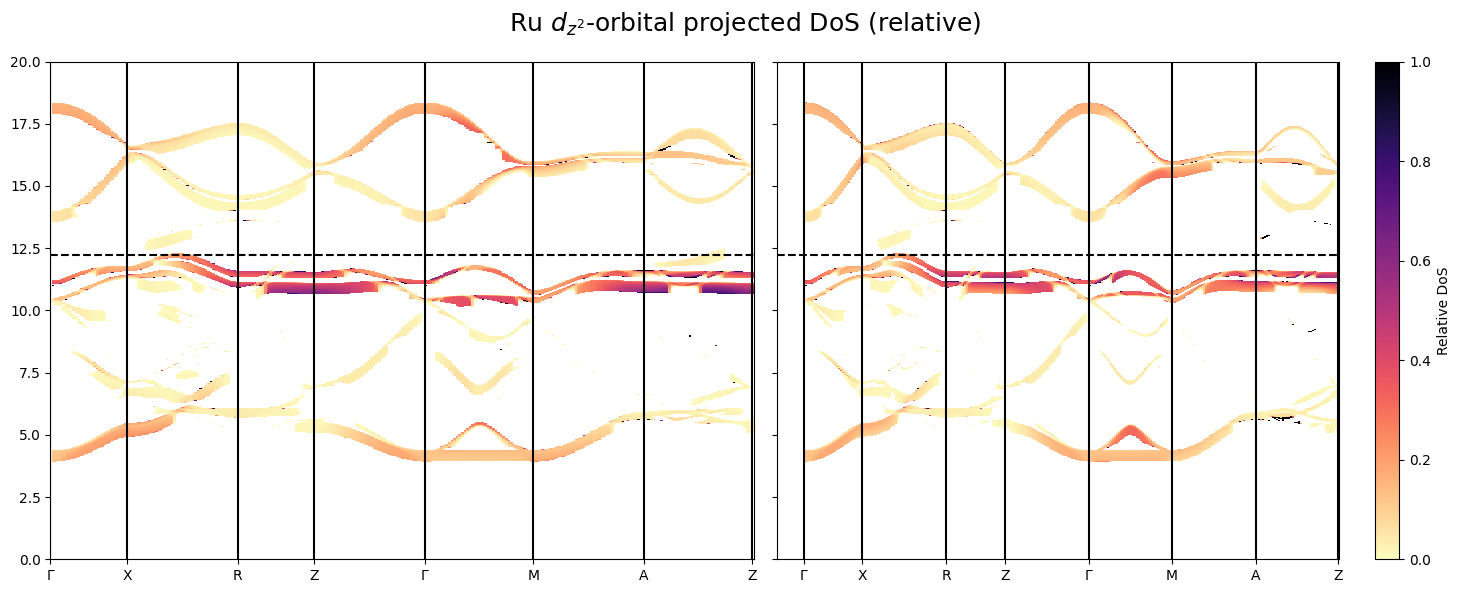

In [29]:

cmr = plt.cm.magma_r
cmr.set_bad(color='white')
fig, ax = plt.subplots(1,2,figsize=(15, 6),sharey=True, tight_layout=True)

band_mask = DoSRudz2up_rel < 0.01
DoSRudz2up_rel_masked = np.ma.masked_where(band_mask, DoSRudz2up_rel)
ax[0].axhline(y = E_F, label='Fermi level', color='black', linestyle='--')
ax[0].set_ylim(0, 20)
ax[0].pcolormesh(k, E, DoSRudz2up_rel_masked.T, cmap=cmr, vmin=0, vmax=1)
ax[0].set_xticks(xtik)
ax[0].set_xticklabels(xtiklabel)
for i in range(len(xtik)):
    ax[0].axvline(x = xtik[i], color='black', linestyle='-')
    ax[1].axvline(x = xtik[i], color='black', linestyle='-')

band_mask = DoSRudz2down_rel < 0.01
DoSRudz2down_rel_masked = np.ma.masked_where(band_mask, DoSRudz2down_rel)
ax[1].axhline(y = E_F, label='Fermi level', color='black', linestyle='--')
ax[1].pcolormesh(k, E, DoSRudz2down_rel_masked.T, cmap=cmr, vmin=0, vmax=1)
ax[1].set_xticks(xtik)
ax[1].set_xticklabels(xtiklabel)
plt.colorbar(ax[1].collections[0], ax=ax[1], label='Relative DoS')
fig.suptitle('Ru $d_{z^2}$-orbital projected DoS (relative)', fontsize=18)


Text(0.5, 0.98, 'Ru $d_{zx}$-orbital projected DoS (relative)')

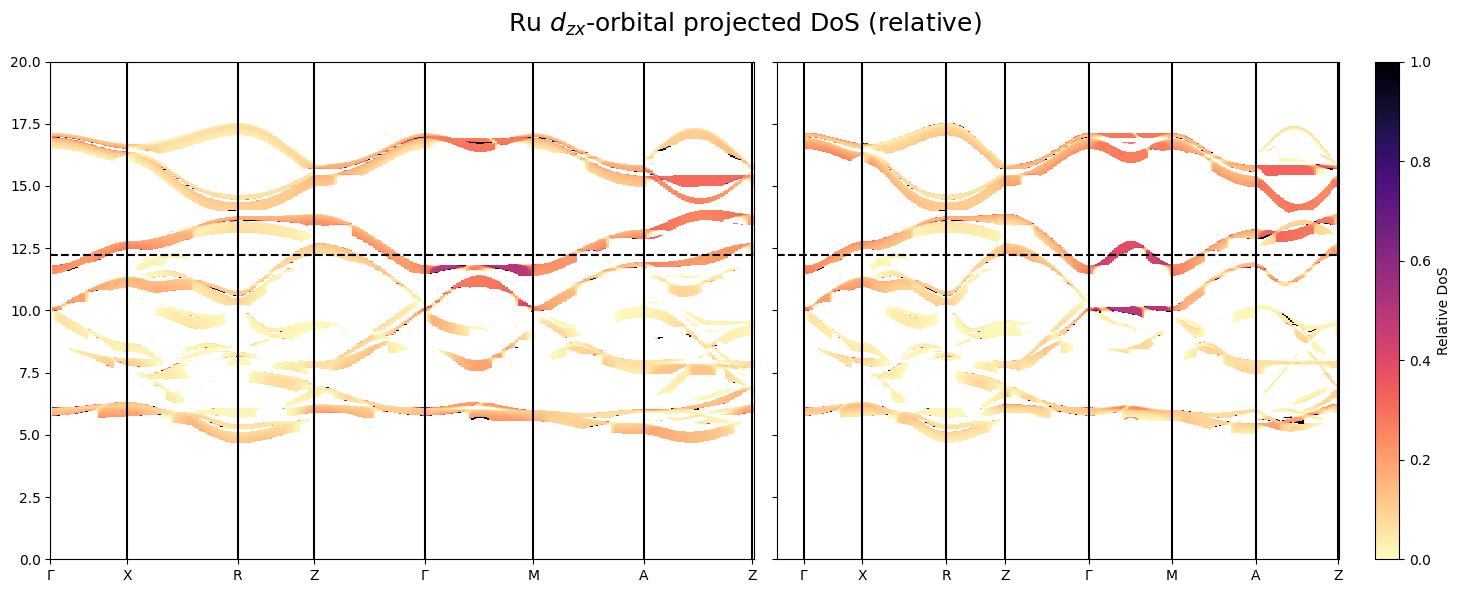

In [33]:
cmr = plt.cm.magma_r
cmr.set_bad(color='white')
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True, tight_layout=True)

band_mask = DoSRudzxup_rel < 0.01
DoSRudzxup_rel_masked = np.ma.masked_where(band_mask, DoSRudzxup_rel)
ax[0].axhline(y=E_F, label='Fermi level', color='black', linestyle='--')
ax[0].set_ylim(0, 20)
ax[0].pcolormesh(k, E, DoSRudzxup_rel_masked.T, cmap=cmr, vmin=0, vmax=1)
ax[0].set_xticks(xtik)
ax[0].set_xticklabels(xtiklabel)
for i in range(len(xtik)):
    ax[0].axvline(x=xtik[i], color='black', linestyle='-')
    ax[1].axvline(x=xtik[i], color='black', linestyle='-')

band_mask = DoSRudzxdown_rel < 0.01
DoSRudzxdown_rel_masked = np.ma.masked_where(band_mask, DoSRudzxdown_rel)
ax[1].axhline(y=E_F, label='Fermi level', color='black', linestyle='--')
ax[1].pcolormesh(k, E, DoSRudzxdown_rel_masked.T, cmap=cmr, vmin=0, vmax=1)
ax[1].set_xticks(xtik)
ax[1].set_xticklabels(xtiklabel)
plt.colorbar(ax[1].collections[0], ax=ax[1], label='Relative DoS')
fig.suptitle('Ru $d_{zx}$-orbital projected DoS (relative)', fontsize=18)

Text(0.5, 0.98, 'Ru $d_{yz}$-orbital projected DoS')

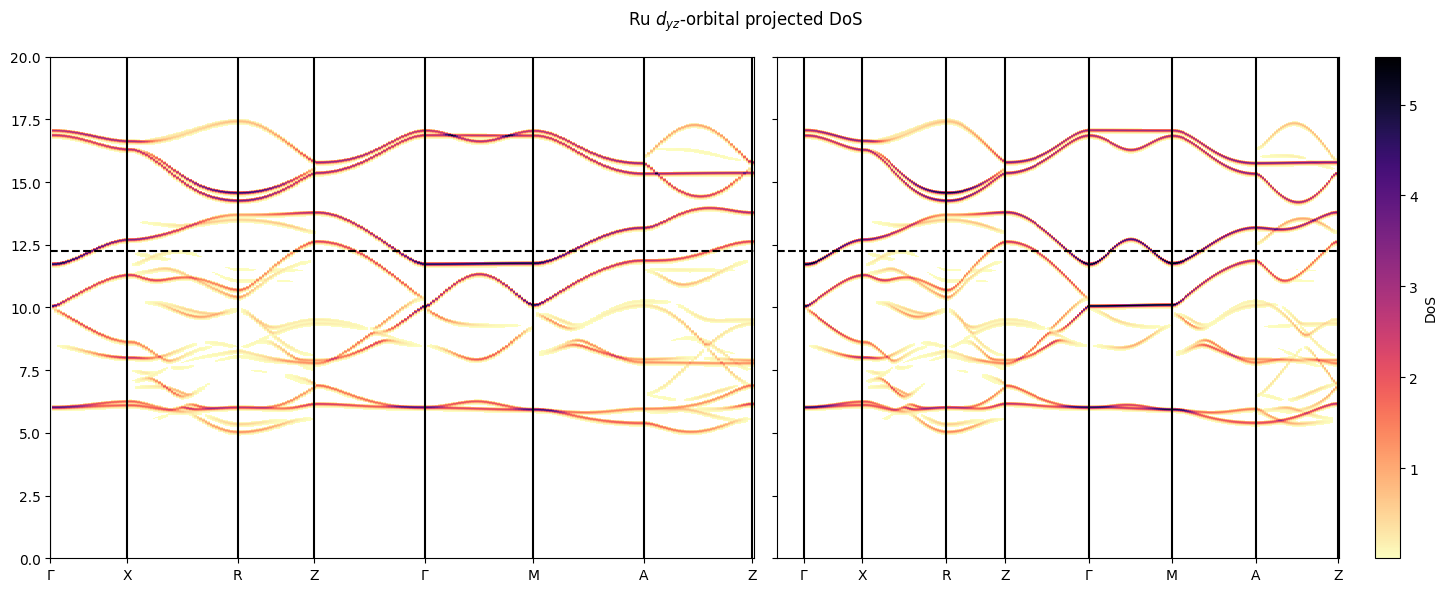

In [32]:

cmr = plt.cm.magma_r
cmr.set_bad(color='white')
fig, ax = plt.subplots(1,2,figsize=(15, 6),sharey=True, tight_layout=True)

band_mask = DoSRudzyup < 0.01
DoSRudzyup[band_mask] = np.nan  # Mask values below threshold
ax[0].axhline(y = E_F, label='Fermi level', color='black', linestyle='--')
ax[0].set_ylim(0,20)
ax[0].pcolormesh(k, E, DoSRudzyup.T, cmap=cmr)
ax[0].set_xticks(xtik)
ax[0].set_xticklabels(xtiklabel)
for i in range(len(xtik)):
    ax[0].axvline(x = xtik[i], color='black', linestyle='-')
    ax[1].axvline(x = xtik[i], color='black', linestyle='-')
band_mask = DoSRudzydown < 0.01
DoSRudzydown[band_mask] = np.nan  # Mask values below threshold
ax[1].axhline(y = E_F, label='Fermi level', color='black', linestyle='--')
ax[1].pcolormesh(k, E, DoSRudzydown.T, cmap=cmr)
ax[1].set_xticks(xtik)
ax[1].set_xticklabels(xtiklabel)
plt.colorbar(ax[1].collections[0], ax=ax[1], label='DoS')
fig.suptitle('Ru $d_{yz}$-orbital projected DoS')

Text(0.5, 0.98, 'Ru $d_{x^2-y^2}$-orbital projected DoS')

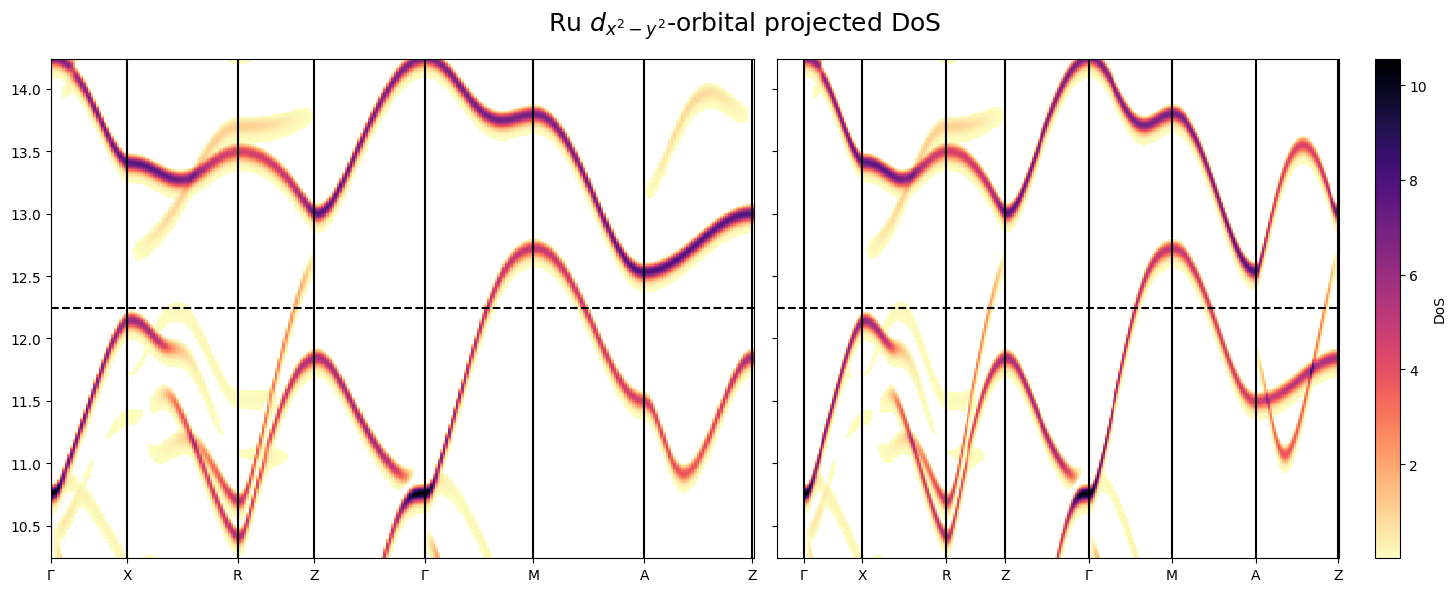

In [ ]:

cmr = plt.cm.magma_r
cmr.set_bad(color='white')
fig, ax = plt.subplots(1,2,figsize=(15, 6),sharey=True, tight_layout=True)

band_mask = DoSRudx2y2up < 0.01
DoSRudx2y2up[band_mask] = np.nan  # Mask values below threshold
ax[0].axhline(y = E_F, label='Fermi level', color='black', linestyle='--')
ax[0].set_ylim(0,20)
ax[0].pcolormesh(k, E, DoSRudx2y2up.T, cmap=cmr)
ax[0].set_xticks(xtik)
ax[0].set_xticklabels(xtiklabel)
for i in range(len(xtik)):
    ax[0].axvline(x = xtik[i], color='black', linestyle='-')
    ax[1].axvline(x = xtik[i], color='black', linestyle='-')
band_mask = DoSRudx2y2down < 0.01
DoSRudx2y2down[band_mask] = np.nan  # Mask values below threshold
ax[1].axhline(y = E_F, label='Fermi level', color='black', linestyle='--')
ax[1].pcolormesh(k, E, DoSRudx2y2down.T, cmap=cmr)
ax[1].set_xticks(xtik)
ax[1].set_xticklabels(xtiklabel)
plt.colorbar(ax[1].collections[0], ax=ax[1], label='DoS')
fig.suptitle('Ru $d_{x^2-y^2}$-orbital projected DoS', fontsize=18)

Text(0.5, 0.98, 'Ru $d_{xy}$-orbital projected DoS')

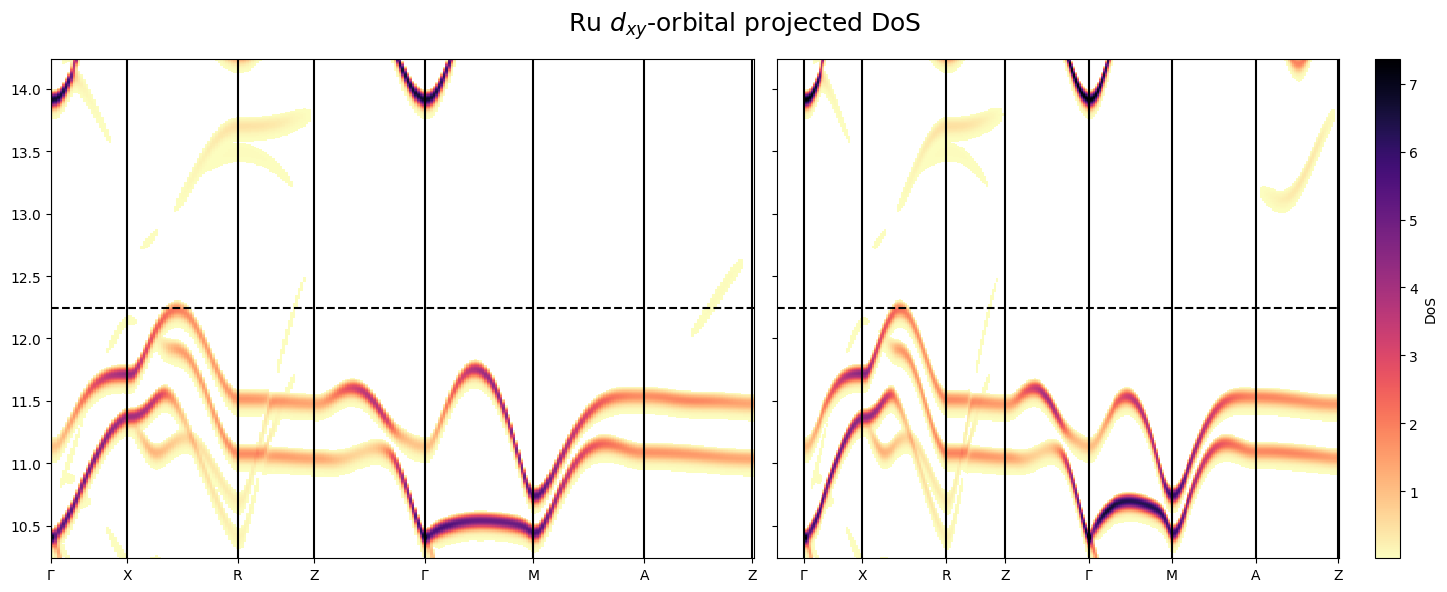

In [25]:

cmr = plt.cm.magma_r
cmr.set_bad(color='white')
fig, ax = plt.subplots(1,2,figsize=(15, 6),sharey=True, tight_layout=True)

band_mask = DoSRudxyup < 0.01
DoSRudxyup[band_mask] = np.nan  # Mask values below threshold
ax[0].axhline(y = E_F, label='Fermi level', color='black', linestyle='--')
ax[0].set_ylim(E_F - 2,E_F + 2)
ax[0].pcolormesh(k, E, DoSRudxyup.T, cmap=cmr)
ax[0].set_xticks(xtik)
ax[0].set_xticklabels(xtiklabel)
for i in range(len(xtik)):
    ax[0].axvline(x = xtik[i], color='black', linestyle='-')
    ax[1].axvline(x = xtik[i], color='black', linestyle='-')
band_mask = DoSRudxydown < 0.01
DoSRudxydown[band_mask] = np.nan  # Mask values below threshold
ax[1].axhline(y = E_F, label='Fermi level', color='black', linestyle='--')
ax[1].pcolormesh(k, E, DoSRudxydown.T, cmap=cmr)
ax[1].set_xticks(xtik)
ax[1].set_xticklabels(xtiklabel)
plt.colorbar(ax[1].collections[0], ax=ax[1], label='DoS')
fig.suptitle('Ru $d_{xy}$-orbital projected DoS', fontsize=18)